# Flow-corrected posterior with multiple pulsars (using CURN)

Also works for single pulsar runs.

In [1]:
from flow_helpers import *

C:\Users\amirt\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\amirt\Documents\GitHub\dsfourier\flow\..\fourierpta.py:228: SyntaxWarning: invalid escape sequence '\P'
  :phi_func:         Function mapping rho to tuple (\Phi^{-1}, log|Phi|). Use


In [2]:
feathers = pathlib.Path(ds.__path__[0] + '/../../data/')

allpsrs = sorted(
    [ds.Pulsar.read_feather(psrfile) for psrfile in list(feathers.glob("*-[JB]*.feather"))],
    key=lambda psr: len(psr.toas), reverse = True
)

In [3]:
npsr = 3
psrs = allpsrs[26:26+npsr]
Tspan = ds.getspan(psrs)

In [ ]:
rn_components = 30
gw_components = 14
powerlaw = ds.powerlaw

# here we fix the RN and WN, which should make the result exact, the WN is fixed through the psr.noisedict
rn_init_params = [{'log10_A': -11.0, 'gamma': 6.5}]*npsr # broad prior
tnequad = False
ecorr = False
fixed_wn = True

pslmodels = fouriermodel(psrs, rn_components, 
                                 rn_init_params= rn_init_params, ecorr = ecorr, tnequad = tnequad, 
                                 powerlaw = powerlaw, fixed_wn = fixed_wn)



In [5]:
logxs = [simple_dict_transformation(pslmodels[_].clogL) for _ in range(npsr)]

In [6]:
pslmodels[0].conditional.params

[]

In [7]:
def compute_zero_quantities(pslmodels, psr_noisedicts):

    Ls, ahat0_list = [], []
    logdet_sigma0_inv = 0.0

    for psr_model, noisedict in zip(pslmodels, psr_noisedicts):

        if psr_model.conditional.params == []:
            ahat0, cf_inv = psr_model.conditional({})
        else:
            ahat0, cf_inv = psr_model.conditional(noisedict)

        logdet_sigma0_inv += 2.0 * jnp.sum(jnp.log(jnp.diag(cf_inv[0])))

        sigma0_psr = jsp.linalg.cho_solve((cf_inv[0], True), jnp.eye(cf_inv[0].shape[0]))
        L_sigma0 = jsp.linalg.cholesky(sigma0_psr, lower=True)

        Ls.append(L_sigma0)
        ahat0_list.append(ahat0)

    return Ls, ahat0_list, logdet_sigma0_inv
            
            

In [8]:
pslmodels[0].logL.params

[]

In [ ]:
# computing _0 quantities
psr_noisedicts = [psr.noisedict for psr in psrs] # fixing the WN
# in this case, logL has no params so no noisedict is not needed
# but we pass it in anyways since it will not affect the results
Ls, ahat0_list, logdet_sigma0_inv = compute_zero_quantities(pslmodels, psr_noisedicts)
            

In [10]:
num_samples = 1024 # num of samples used in flow
num_params  = 2*rn_components # num of params to fit flow to (in this case, 60 RN coefficient / psr)
rng = jax.random.key(0)

# choose your flow
flow_key, rng = jax.random.split(rng)
flow = masked_autoregressive_flow( flow_key, base_dist=StandardNormal((num_params,)),
    flow_layers=2, nn_width=16, nn_depth=4, invert=True)

# fitting a flow
trained_flows, train_keys = fit_flows(pslmodels, logxs, ahat0_list, Ls, 
                                    num_samples, rng, flow = flow)

Fitting flow for pulsar J1125+7819


 21%|██▏       | 213/1001 [03:14<12:00,  1.09it/s, loss=-92620.66]

Early stopping at iteration 213
Fitting flow for pulsar B1855+09



 23%|██▎       | 229/1001 [03:59<13:26,  1.04s/it, loss=-90764.75]

Early stopping at iteration 229
Fitting flow for pulsar J1832-0836



 24%|██▎       | 236/1001 [03:54<12:41,  1.01it/s, loss=-89788.80]

Early stopping at iteration 236


In [11]:
# computing _f quantities
num_flow_samples = 100000 # rather large to get good estimate of ahat_f and Sigma_f from samples
ahat_f, Sigma_f, L_f = gauss_approx_flow_mpsrs(trained_flows, train_keys, ahat0_list, 
                                                Ls, num_flow_samples=num_flow_samples)

# precomputing quantities needed in likelihood model
Sigma_f_inv, logdet_arr, b_flow, quad_f = eval_flow_quantity_mpsrs(ahat_f, Sigma_f, L_f)

_, f, df = construct_freqs(psrs, num_frequencies=rn_components)

# extracting TtNT for all psrs
TNT_flow, logdet_phi0 = TtNT_mpsrs(Sigma_f_inv, params_list=[rn_init_params[0]] * npsr,
                                f=f, df=df, powerlaw=powerlaw)

log_const = 0.5 * logdet_phi0


In [12]:
psrnames = [psr.name for psr in pslmodels]
rn_amp_keys, rn_gamma_keys = create_rn_keys(psrnames)

In [13]:
crn_gamma_key = "crn_gamma"
crn_log10A_key = "crn_log10_A"
crn_components = 14

commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, rn_components, T=Tspan, name='red_noise')
commongp_crn =ds.makecommongp_fourier(psrs, ds.powerlaw, components=crn_components, T=Tspan, name='crn',
                                                           common=[crn_log10A_key, crn_gamma_key])
getN_common = commongp.Phi.getN 
getN_crn = commongp_crn.Phi.getN

In [14]:
phi_crn_args = (crn_components, rn_amp_keys, rn_gamma_keys, crn_log10A_key, 
        crn_gamma_key, getN_common, getN_crn)

phi_crn_partial = jax.jit(lambda rho: phi_crn(rho, *phi_crn_args))

In [15]:
logL_flow_list = [flow.log_prob for flow in trained_flows]
# arguments needed for the non-flow-corrected posterior
base_model_args = (b_flow, phi_crn_partial, log_const, TNT_flow, npsr, rn_components,
                   rn_amp_keys, rn_gamma_keys, crn_log10A_key, crn_gamma_key,)

flow_model = make_model_crn_flow( *base_model_args, logL_flow_list=logL_flow_list,
    ahat_0=jnp.stack(ahat0_list), L_0=jnp.stack(Ls), ahat_f=ahat_f, L_sigma_f=L_f,)

init_params = {**{key: -14.0 for key in rn_amp_keys},
    **{key: 4.0 for key in rn_gamma_keys},
    crn_log10A_key: -12.0, crn_gamma_key: 4.0,
      "xi": jnp.zeros((npsr, 2 * rn_components))}

kernel_flow  = infer.NUTS(flow_model)
sampler_flow = infer.MCMC(kernel_flow, num_warmup=1000, num_samples=2000)
sampler_flow.run(jax.random.PRNGKey(2), init_params = init_params)
samples_flow = sampler_flow.get_samples()
sampler_flow.print_summary()

sample: 100%|██████████| 3000/3000 [28:08<00:00,  1.78it/s, 63 steps of size 6.14e-02. acc. prob=0.94]  



                                    mean       std    median      5.0%     95.0%     n_eff     r_hat
      B1855+09_red_noise_gamma      0.60      0.36      0.58      0.00      1.09    711.54      1.00
    B1855+09_red_noise_log10_A    -12.62      0.06    -12.62    -12.73    -12.52   3007.41      1.00
    J1125+7819_red_noise_gamma      1.96      1.79      1.30      0.00      4.96    596.21      1.00
  J1125+7819_red_noise_log10_A    -14.39      2.31    -12.94    -18.40    -12.30    358.94      1.00
    J1832-0836_red_noise_gamma      3.32      1.97      3.22      0.05      6.24   3610.84      1.00
  J1832-0836_red_noise_log10_A    -16.80      1.91    -16.88    -19.98    -14.11    998.40      1.00
                     crn_gamma      4.45      1.59      4.56      2.35      7.00   1723.76      1.00
                   crn_log10_A    -14.93      1.26    -14.72    -16.13    -13.20    422.92      1.00
                       xi[0,0]     -0.04      1.02     -0.03     -1.60      1.77   3048.41

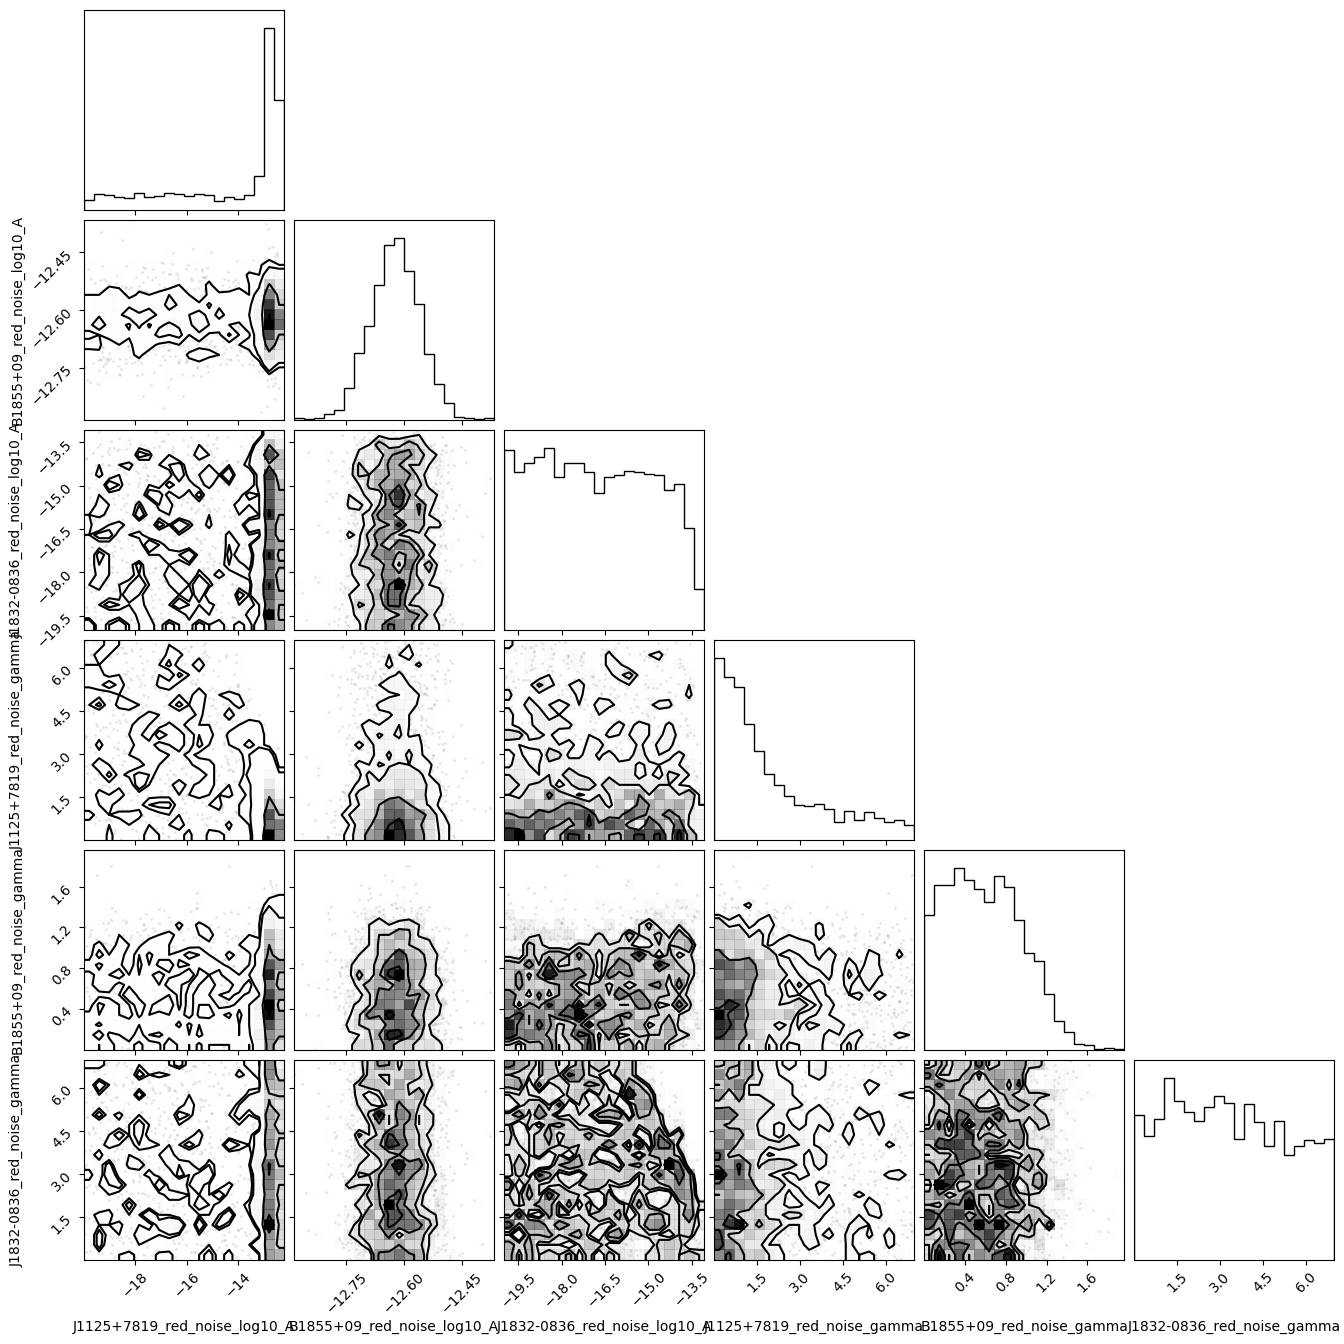

In [16]:
irn_samples_flow = {k: samples_flow[k] for k in rn_amp_keys + rn_gamma_keys}
corner.corner(irn_samples_flow)
plt.show()

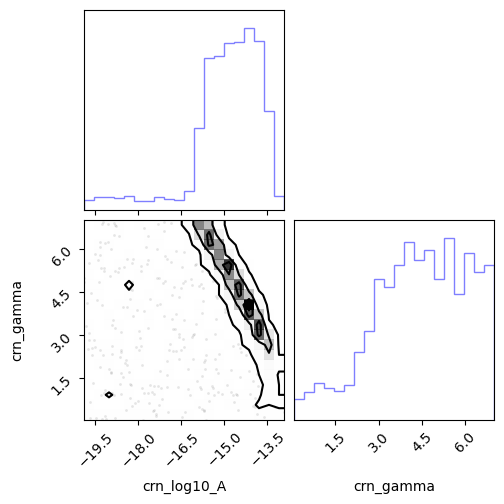

In [17]:
crn_samples_flow = {k: samples_flow[k] for k in [crn_log10A_key, crn_gamma_key]}
corner.corner(crn_samples_flow, hist_kwargs = {"density": True, "alpha": 0.5, "color": "blue"})
plt.show()

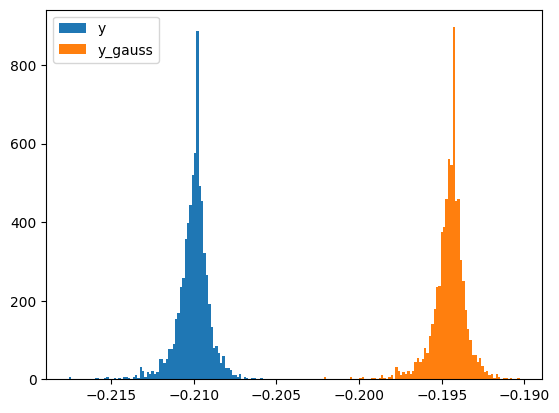

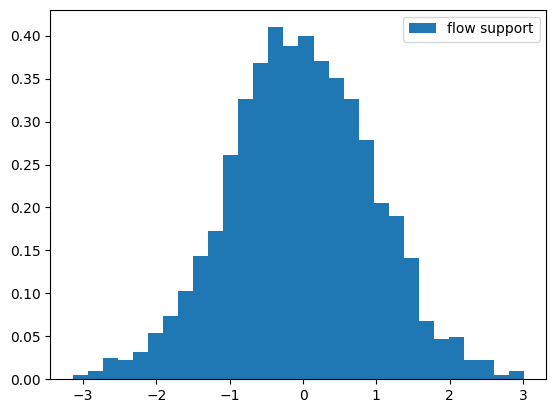

In [59]:
psr_idx = 0
coeff_idx  = 5
y_flow_support = trained_flows[psr_idx].sample(jax.random.key(0), sample_shape=(2000,))
plt.hist(samples_flow["y"][:,psr_idx,coeff_idx], density = True, bins = 'auto', label = "y")
plt.hist(samples_flow["y_gauss"][:,psr_idx,coeff_idx], density = True, bins = 'auto', label = "y_gauss")
plt.legend()
plt.show()
plt.hist(y_flow_support[:, coeff_idx], density = True, bins = 'auto', label = "flow support")
plt.legend()
plt.show()

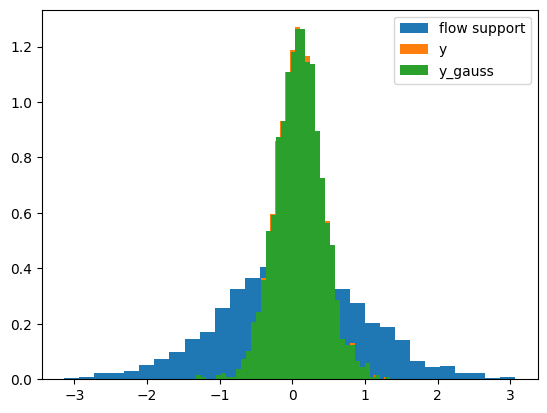

In [62]:
psr_idx = 1
coeff_idx  = 5
y_flow_support = trained_flows[psr_idx].sample(jax.random.key(0), sample_shape=(2000,))
plt.hist(y_flow_support[:, coeff_idx], density = True, bins = 'auto', label = "flow support")
plt.hist(samples_flow["y"][:,psr_idx,coeff_idx], density = True, bins = 'auto', label = "y")
plt.hist(samples_flow["y_gauss"][:,psr_idx,coeff_idx], density = True, bins = 'auto', label = "y_gauss")
plt.legend()
plt.show()


In [28]:
m_crn = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
                            ds.makegp_timing(psr, svd=True),
                            ds.makenoise_measurement(psr, noisedict=psr.noisedict, ecorr=ecorr)]) for psr in psrs],
            commongp = [ds.makecommongp_fourier(psrs, ds.powerlaw, components=rn_components, T=Tspan, name='red_noise'),
                        ds.makecommongp_fourier(psrs, ds.powerlaw, components=crn_components, T=Tspan, name='crn',
                                                           common=[crn_log10A_key, crn_gamma_key])])

In [31]:
def log_prior_rho_crn(rho):
    log10As = jnp.array([rho[k] for k in rn_amp_keys] + [rho[crn_log10A_key]])
    gammas  = jnp.array([rho[k] for k in rn_gamma_keys] + [rho[crn_gamma_key]])

    ok = jnp.all((log10As >= -20) & (log10As <= -11)) & jnp.all((gammas >= 0) & (gammas <= 7))
    log_prior_val = jnp.where(ok, 0.0, -jnp.inf)
    return log_prior_val

def potential_ds_crn(rho):
        lp = log_prior_rho_crn(rho)
        return - m_crn.logL(rho) - lp
    
kernel_ds_crn = infer.NUTS(potential_fn=potential_ds_crn)
sampler_ds_crn = infer.MCMC(kernel_ds_crn, num_warmup=1000, num_samples=2000, num_chains=1, progress_bar=True)
init_rho_crn = {**{key: -14.0 for key in rn_amp_keys},
    **{key: 4.0 for key in rn_gamma_keys},
    crn_log10A_key: -12.0,
    crn_gamma_key: 4.0}

sampler_ds_crn.run(jax.random.key(1), init_params=init_rho_crn)

samples_ds_crn = sampler_ds_crn.get_samples()
sampler_ds_crn.print_summary()


sample: 100%|██████████| 3000/3000 [02:22<00:00, 21.11it/s, 23 steps of size 4.49e-02. acc. prob=0.87] 


                                    mean       std    median      5.0%     95.0%     n_eff     r_hat
      B1855+09_red_noise_gamma      0.50      0.30      0.47      0.03      0.92     63.79      1.05
    B1855+09_red_noise_log10_A    -12.62      0.06    -12.62    -12.73    -12.53     94.82      1.00
    J1125+7819_red_noise_gamma      2.20      2.00      1.42      0.00      5.69     32.97      1.08
  J1125+7819_red_noise_log10_A    -14.46      2.25    -13.09    -18.30    -12.34     17.29      1.03
    J1832-0836_red_noise_gamma      3.40      2.03      3.29      0.28      6.48     42.92      1.02
  J1832-0836_red_noise_log10_A    -16.85      1.78    -16.96    -19.44    -13.96     73.03      1.01
                     crn_gamma      4.63      1.49      4.52      2.81      6.96     20.36      1.03
                   crn_log10_A    -14.75      0.91    -14.63    -15.96    -13.47     16.18      1.12

Number of divergences: 1955


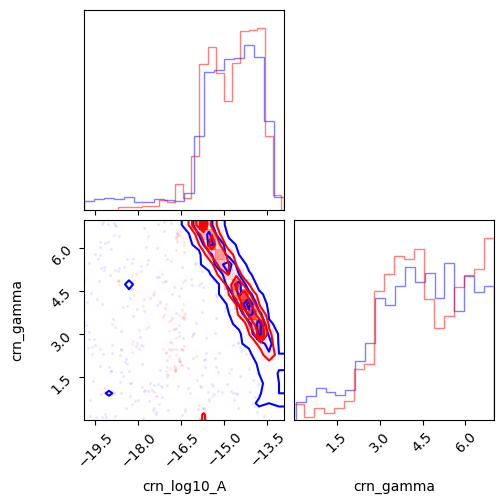

In [32]:
crn_hyper_ds = {k: samples_ds_crn[k] for k in [crn_log10A_key, crn_gamma_key]}
figure = corner.corner(crn_samples_flow, hist_kwargs = {"density": True, "alpha": 0.5, "color": "blue"}, color = 'blue')
corner.corner(crn_hyper_ds, hist_kwargs = {"density": True, "alpha": 0.5, "color": "red"}, color = 'red', fig = figure)

plt.show()

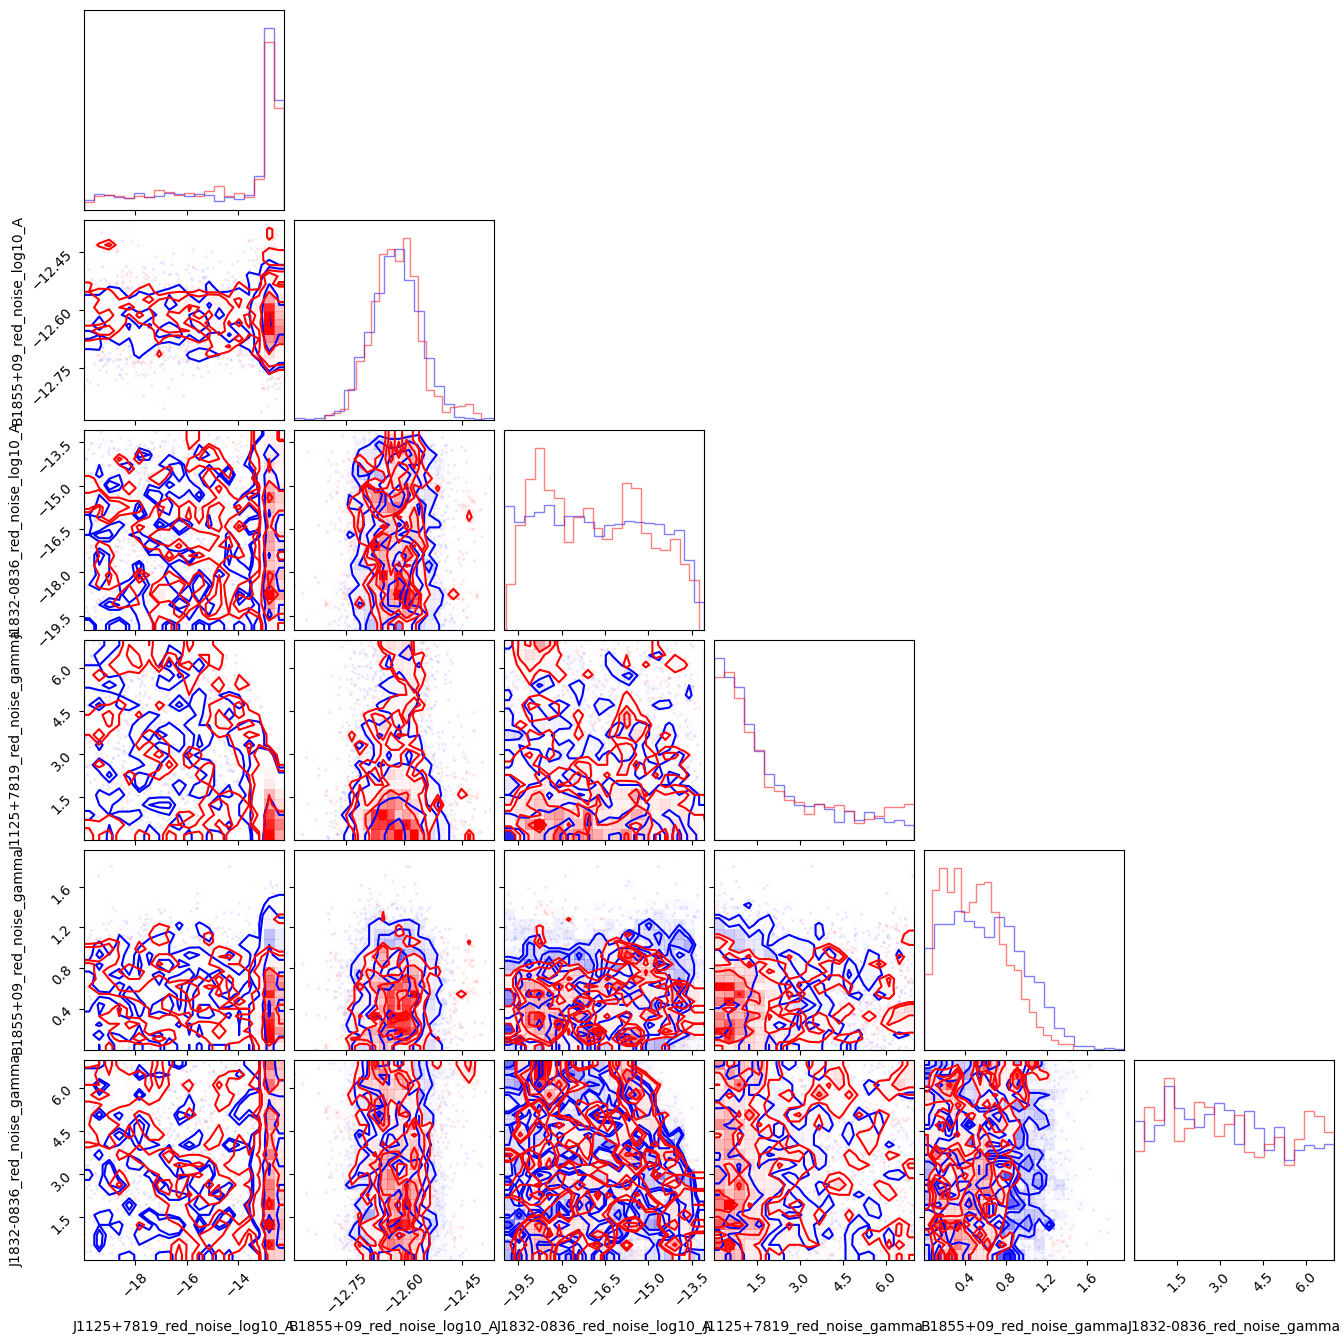

In [33]:
irn_samples_ds_crn = {k: samples_ds_crn[k] for k in rn_amp_keys + rn_gamma_keys}
figure = corner.corner(irn_samples_flow, hist_kwargs = {"density": True, "alpha": 0.5, "color": "blue"}, color='blue')
corner.corner(irn_samples_ds_crn, hist_kwargs = {"density": True, "alpha": 0.5, "color": "red"}, color='red', fig=figure)
plt.show()
